In [55]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

print("Uploaded file:", filename)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Uploaded file: WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv(filename)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
df.shape

(7043, 21)

In [59]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [61]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [62]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
(df['TotalCharges'].astype(str).str.strip() == '').sum()

np.int64(11)

In [65]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Data Type:", df['TotalCharges'].dtype)
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

Data Type: float64
Missing TotalCharges: 11


In [66]:
df[df['TotalCharges'].isnull()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [67]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing TotalCharges after cleaning:")
print(df['TotalCharges'].isnull().sum())

Missing TotalCharges after cleaning:
0


In [68]:
df = df.drop('customerID', axis=1)

print("Dataset Shape:", df.shape)
print("customerID present:", 'customerID' in df.columns)

Dataset Shape: (7043, 20)
customerID present: False


In [69]:
print("Churn Counts:")
print(df['Churn'].value_counts())

print("\nChurn Percentage:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


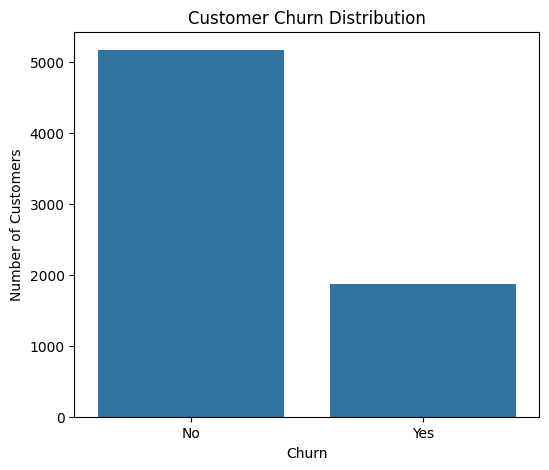

In [70]:
plt.figure(figsize=(6,5))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

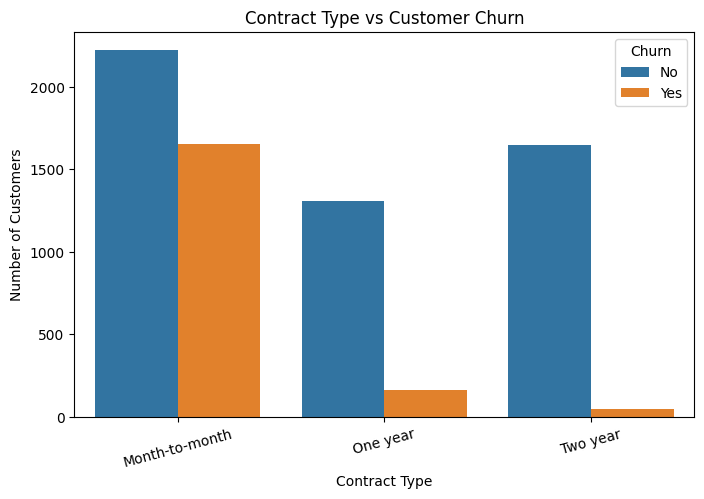

In [71]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type vs Customer Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

plt.show()

In [72]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


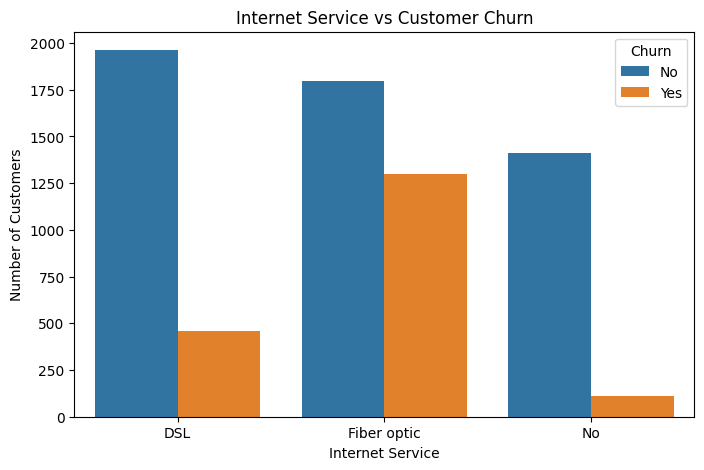

In [73]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title('Internet Service vs Customer Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

In [74]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


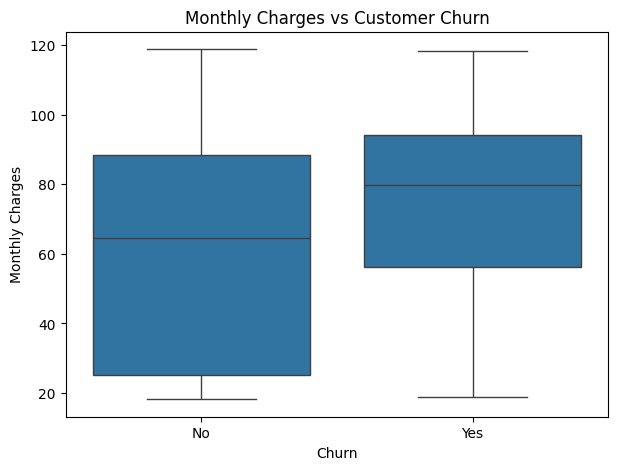

In [75]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

In [76]:
monthly_charge_summary = df.groupby('Churn')['MonthlyCharges'].mean()

print("Average Monthly Charges by Churn:")
print(monthly_charge_summary.round(2))

Average Monthly Charges by Churn:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


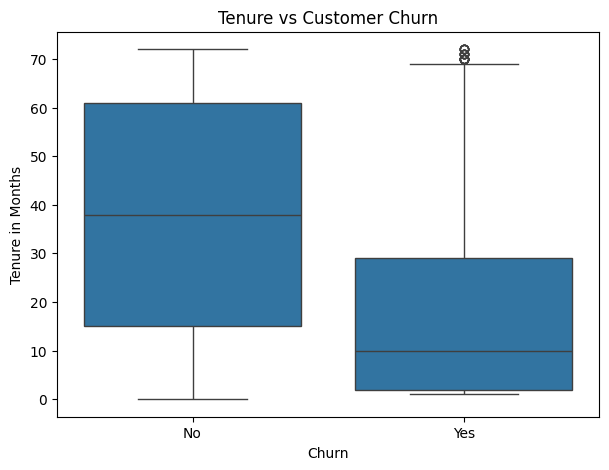

In [77]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure in Months')

plt.show()

In [78]:
tenure_summary = df.groupby('Churn')['tenure'].agg(
    ['mean', 'median']
)

print("Tenure Summary by Churn:")
print(tenure_summary.round(2))

Tenure Summary by Churn:
        mean  median
Churn               
No     37.57    38.0
Yes    17.98    10.0


In [79]:
print("KEY EDA OBSERVATIONS")

print("\nOverall Churn Rate:")
print(round((df['Churn'] == 'Yes').mean() * 100, 2), "%")

print("\nChurn Rate by Contract:")
print(
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)

print("\nChurn Rate by Internet Service:")
print(
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)

print("\nAverage Monthly Charges by Churn:")
print(
    df.groupby('Churn')['MonthlyCharges']
    .mean()
    .round(2)
)

print("\nAverage Tenure by Churn:")
print(
    df.groupby('Churn')['tenure']
    .mean()
    .round(2)
)

KEY EDA OBSERVATIONS

Overall Churn Rate:
26.54 %

Churn Rate by Contract:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

Churn Rate by Internet Service:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

Average Monthly Charges by Churn:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

Average Tenure by Churn:
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


In [80]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

print("Churn Encoding:")
print("No = 0")
print("Yes = 1")

print("\nEncoded Churn Values:")
print(df['Churn'].value_counts().sort_index())

Churn Encoding:
No = 0
Yes = 1

Encoded Churn Values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [81]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [82]:
selected_features = [
    column for column in df_encoded.columns
    if column != 'Churn'
]

print("Number of Selected Features:", len(selected_features))

print("\nSelected Features:")
for feature in selected_features:
    print(feature)

print("\ncustomerID present:", 'customerID' in df_encoded.columns)

Number of Selected Features: 30

Selected Features:
SeniorCitizen
tenure
MonthlyCharges
TotalCharges
gender_Male
Partner_Yes
Dependents_Yes
PhoneService_Yes
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineSecurity_Yes
OnlineBackup_No internet service
OnlineBackup_Yes
DeviceProtection_No internet service
DeviceProtection_Yes
TechSupport_No internet service
TechSupport_Yes
StreamingTV_No internet service
StreamingTV_Yes
StreamingMovies_No internet service
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaperlessBilling_Yes
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check

customerID present: False


In [83]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget Variable Preview:")
print(y.head())

X shape: (7043, 30)
y shape: (7043,)

Target Variable Preview:
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Test Split Completed")
print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

Train Test Split Completed
Training Size: 5634
Testing Size: 1409


In [85]:
print("Training Data Shapes")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nFirst 5 Training Target Values:")
print(y_train.head())

Training Data Shapes
X_train shape: (5634, 30)
y_train shape: (5634,)

First 5 Training Target Values:
3738    0
3151    0
4860    0
3867    0
3810    0
Name: Churn, dtype: int64


In [86]:
print("Testing Data Shapes")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 5 Testing Target Values:")
print(y_test.head())

Testing Data Shapes
X_test shape: (1409, 30)
y_test shape: (1409,)

First 5 Testing Target Values:
437     0
2280    0
2235    0
4460    0
3761    0
Name: Churn, dtype: int64


In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [88]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", round(log_accuracy, 4))
print("Accuracy Percentage:", round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.807
Accuracy Percentage: 80.7 %


In [89]:
from sklearn.metrics import precision_score

log_precision = precision_score(y_test, log_pred)

print("Logistic Regression Precision:", round(log_precision, 4))

Logistic Regression Precision: 0.6584


In [90]:
from sklearn.metrics import recall_score

log_recall = recall_score(y_test, log_pred)

print("Logistic Regression Recall:", round(log_recall, 4))

Logistic Regression Recall: 0.5668


In [91]:
from sklearn.metrics import f1_score

log_f1 = f1_score(y_test, log_pred)

print("Logistic Regression F1 Score:", round(log_f1, 4))

Logistic Regression F1 Score: 0.6092


In [92]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")

print(classification_report(
    y_test,
    log_pred,
    target_names=['No Churn', 'Churn']
))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



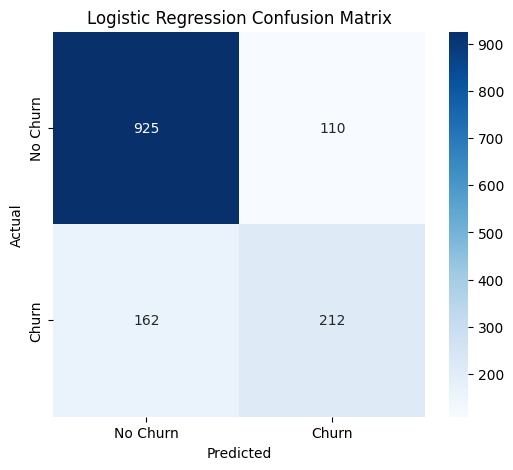

In [93]:
from sklearn.metrics import confusion_matrix

log_cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    log_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [94]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [95]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Accuracy Percentage:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 0.785
Accuracy Percentage: 78.5 %


In [96]:
rf_precision = precision_score(y_test, rf_pred)

print("Random Forest Precision:", round(rf_precision, 4))

Random Forest Precision: 0.6179


In [97]:
rf_recall = recall_score(y_test, rf_pred)

print("Random Forest Recall:", round(rf_recall, 4))

Random Forest Recall: 0.4973


In [98]:
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest F1 Score:", round(rf_f1, 4))

Random Forest F1 Score: 0.5511


In [99]:
print("Random Forest Classification Report:")

print(classification_report(
    y_test,
    rf_pred,
    target_names=['No Churn', 'Churn']
))

Random Forest Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



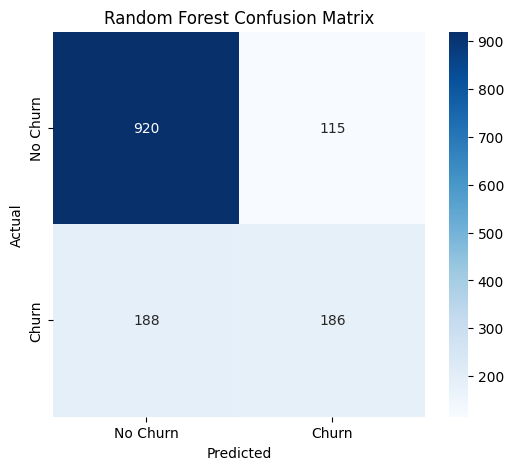

In [100]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [101]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy],
    'Precision': [log_precision, rf_precision],
    'Recall': [log_recall, rf_recall],
    'F1 Score': [log_f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Random Forest,0.784954,0.617940,0.497326,0.551111


In [102]:
best_model = comparison.loc[
    comparison['F1 Score'].idxmax()
]

print("Best Performing Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy'], 4))
print("Precision:", round(best_model['Precision'], 4))
print("Recall:", round(best_model['Recall'], 4))
print("F1 Score:", round(best_model['F1 Score'], 4))

Best Performing Model: Logistic Regression
Accuracy: 0.807
Precision: 0.6584
Recall: 0.5668
F1 Score: 0.6092


In [103]:
print("MODEL SELECTION JUSTIFICATION")

print("\nLogistic Regression")
print("Accuracy:", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall:", round(log_recall, 4))
print("F1 Score:", round(log_f1, 4))

print("\nRandom Forest")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))

print("\nSelected Model: Logistic Regression")
print("Reason: Higher Accuracy, Precision, Recall and F1 Score.")

MODEL SELECTION JUSTIFICATION

Logistic Regression
Accuracy: 0.807
Precision: 0.6584
Recall: 0.5668
F1 Score: 0.6092

Random Forest
Accuracy: 0.785
Precision: 0.6179
Recall: 0.4973
F1 Score: 0.5511

Selected Model: Logistic Regression
Reason: Higher Accuracy, Precision, Recall and F1 Score.


In [104]:
sample_customer = pd.DataFrame({
    'gender': ['Male'],
    'SeniorCitizen': [0],
    'Partner': ['No'],
    'Dependents': ['No'],
    'tenure': [12],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [85.0],
    'TotalCharges': [1020.0]
})

sample_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,No,No,12,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.0,1020.0


In [105]:
sample_encoded = pd.get_dummies(
    sample_customer,
    dtype=int
)

sample_encoded = sample_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

sample_scaled = scaler.transform(sample_encoded)

prediction = log_model.predict(sample_scaled)[0]

print("Sample data encoded successfully.")
print("Sample shape:", sample_encoded.shape)
print("Prediction process completed.")

Sample data encoded successfully.
Sample shape: (1, 30)
Prediction process completed.


In [106]:
if prediction == 1:
    print("Prediction: Churn")
else:
    print("Prediction: No Churn")

Prediction: Churn
